(9380, 27)
shape: (3, 2)
┌────────────────┬────────────┐
│ FullTimeResult ┆ proportion │
│ ---            ┆ ---        │
│ str            ┆ f64        │
╞════════════════╪════════════╡
│ A              ┆ 0.295096   │
│ D              ┆ 0.246588   │
│ H              ┆ 0.458316   │
└────────────────┴────────────┘


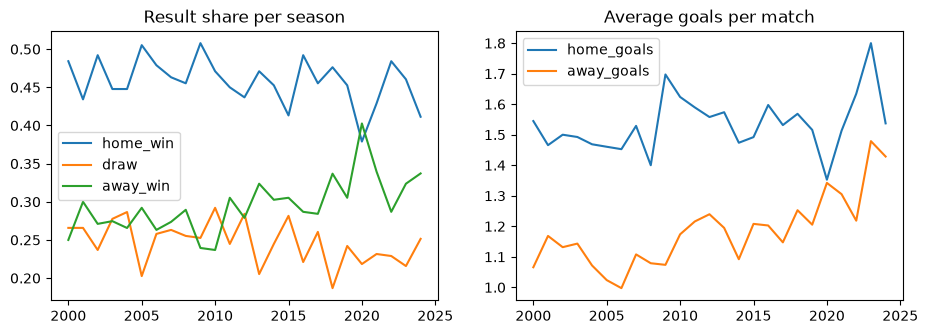

In [2]:
import matplotlib.pyplot as plt
import polars as pl

elo = pl.read_csv("../data/elo_matches.csv", try_parse_dates=True).with_columns(
    pl.col("Season").str.slice(0, 4).cast(pl.Int32).alias("year")
)
print(elo.shape)
print(elo["FullTimeResult"].value_counts(normalize=True))

by_year = (
    elo.group_by("year")
    .agg(
        (pl.col("FullTimeResult") == "H").mean().alias("home_win"),
        (pl.col("FullTimeResult") == "D").mean().alias("draw"),
        (pl.col("FullTimeResult") == "A").mean().alias("away_win"),
        pl.col("FullTimeHomeGoals").mean().alias("home_goals"),
        pl.col("FullTimeAwayGoals").mean().alias("away_goals"),
    )
    .sort("year")
)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for c in ("home_win", "draw", "away_win"):
    ax[0].plot(by_year["year"], by_year[c], label=c)
ax[0].legend()
ax[0].set_title("Result share per season")
for c in ("home_goals", "away_goals"):
    ax[1].plot(by_year["year"], by_year[c], label=c)
ax[1].legend()
ax[1].set_title("Average goals per match")
plt.show()

shape: (10, 4)
┌─────┬──────────┬──────────┬──────┐
│ b   ┆ pred     ┆ actual   ┆ n    │
│ --- ┆ ---      ┆ ---      ┆ ---  │
│ f64 ┆ f64      ┆ f64      ┆ u32  │
╞═════╪══════════╪══════════╪══════╡
│ 0.0 ┆ 0.092522 ┆ 0.0      ┆ 2    │
│ 1.0 ┆ 0.172856 ┆ 0.166667 ┆ 114  │
│ 2.0 ┆ 0.257009 ┆ 0.254065 ┆ 492  │
│ 3.0 ┆ 0.352351 ┆ 0.35706  ┆ 857  │
│ 4.0 ┆ 0.453678 ┆ 0.437788 ┆ 1302 │
│ 5.0 ┆ 0.552873 ┆ 0.558189 ┆ 2131 │
│ 6.0 ┆ 0.646752 ┆ 0.644318 ┆ 2103 │
│ 7.0 ┆ 0.747951 ┆ 0.750893 ┆ 1399 │
│ 8.0 ┆ 0.842475 ┆ 0.855556 ┆ 900  │
│ 9.0 ┆ 0.915704 ┆ 0.88125  ┆ 80   │
└─────┴──────────┴──────────┴──────┘


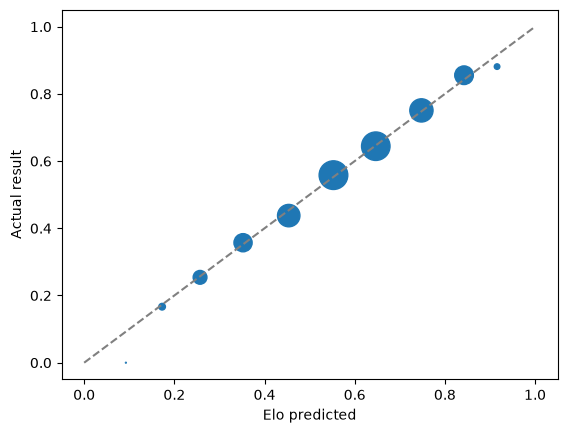

In [3]:
cal = (
    elo.with_columns((pl.col("exp_home") * 10).floor().alias("b"))
    .group_by("b")
    .agg(
        pl.col("exp_home").mean().alias("pred"),
        pl.col("score_home").mean().alias("actual"),
        pl.len().alias("n"),
    )
    .sort("b")
)
print(cal)
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.scatter(cal["pred"], cal["actual"], s=cal["n"] / 5)
plt.xlabel("Elo predicted")
plt.ylabel("Actual result")
plt.show()

In [4]:
f = (
    pl.read_csv("../data/features.csv", try_parse_dates=True)
    .with_columns(
        (pl.col("FullTimeHomeGoals") - pl.col("FullTimeAwayGoals")).alias("gd"),
        ((pl.col("h_xgf5") - pl.col("h_xga5")) - (pl.col("a_xgf5") - pl.col("a_xga5"))).alias(
            "xg_diff5"
        ),
    )
    .drop_nulls("xg_diff5")
)

print(
    f.select(
        pl.corr("gd", "elo_diff").alias("gd~elo"),
        pl.corr("gd", "xg_diff5").alias("gd~xg5"),
        pl.corr("elo_diff", "xg_diff5").alias("elo~xg5"),
    )
)

shape: (1, 3)
┌──────────┬──────────┬──────────┐
│ gd~elo   ┆ gd~xg5   ┆ elo~xg5  │
│ ---      ┆ ---      ┆ ---      │
│ f64      ┆ f64      ┆ f64      │
╞══════════╪══════════╪══════════╡
│ 0.452796 ┆ 0.384697 ┆ 0.715032 │
└──────────┴──────────┴──────────┘


In [5]:
xg = pl.read_csv("../data/xg_schedule.csv").filter(pl.col("home_xg").is_not_null())
print(
    xg.select(
        pl.col("home_xg").mean(),
        pl.col("home_goals").mean(),
        pl.col("away_xg").mean(),
        pl.col("away_goals").mean(),
        pl.corr("home_xg", "home_goals").alias("corr_home"),
    )
)

shape: (1, 5)
┌──────────┬────────────┬──────────┬────────────┬───────────┐
│ home_xg  ┆ home_goals ┆ away_xg  ┆ away_goals ┆ corr_home │
│ ---      ┆ ---        ┆ ---      ┆ ---        ┆ ---       │
│ f64      ┆ f64        ┆ f64      ┆ f64        ┆ f64       │
╞══════════╪════════════╪══════════╪════════════╪═══════════╡
│ 1.569064 ┆ 1.544737   ┆ 1.262852 ┆ 1.261244   ┆ 0.625914  │
└──────────┴────────────┴──────────┴────────────┴───────────┘


In [6]:
lu = pl.read_csv("../data/lineups_csv/lineups_all.csv").with_columns(
    pl.col("game").str.slice(0, 10).str.to_date().alias("date")
)
xi = (
    lu.filter(pl.col("is_starter"))
    .group_by("team", "date", "game")
    .agg(pl.col("player").sort().alias("xi"), pl.len().alias("n"))
    .sort("team", "date")
)
print(xi["n"].value_counts().sort("n"))

rows = []
for (team,), g in xi.group_by("team", maintain_order=True):
    prev = None
    for d, x in zip(g["date"], g["xi"]):
        if prev is not None:
            rows.append((team, d, 11 - len(set(prev) & set(x))))
        prev = x
chg = pl.DataFrame(rows, schema=["team", "date", "changes"], orient="row")
print(chg["changes"].describe())

shape: (1, 2)
┌─────┬───────┐
│ n   ┆ count │
│ --- ┆ ---   │
│ u32 ┆ u32   │
╞═════╪═══════╡
│ 11  ┆ 7600  │
└─────┴───────┘
shape: (9, 2)
┌────────────┬──────────┐
│ statistic  ┆ value    │
│ ---        ┆ ---      │
│ str        ┆ f64      │
╞════════════╪══════════╡
│ count      ┆ 7566.0   │
│ null_count ┆ 0.0      │
│ mean       ┆ 2.268306 │
│ std        ┆ 1.627398 │
│ min        ┆ 0.0      │
│ 25%        ┆ 1.0      │
│ 50%        ┆ 2.0      │
│ 75%        ┆ 3.0      │
│ max        ┆ 11.0     │
└────────────┴──────────┘
